# MVP Análise de Dados e Boas Práticas

**Nome:** Tony Ribeiro Sá

**Matrícula:** 4052025001862

**Dataset:** [Titanic dataset](https://raw.githubusercontent.com/Tony-maxrs/MVP-Titanic-Analise/refs/heads/main/titanic%20dataset.csv)

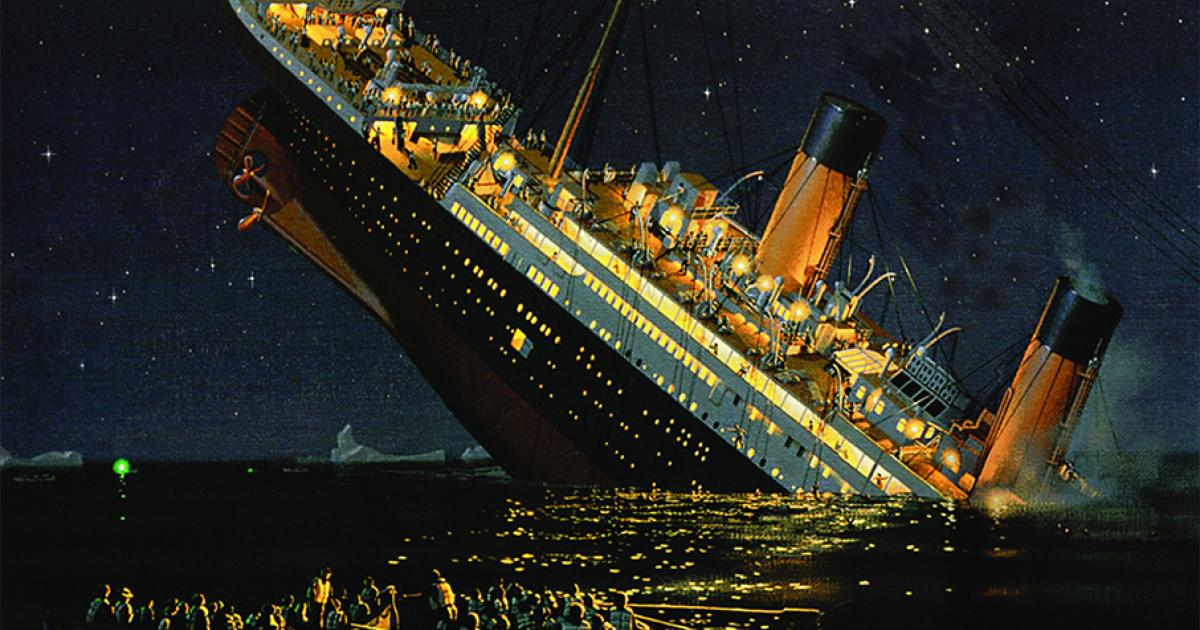

# Descrição do Problema

O objetivo deste trabalho é analisar os fatores que influenciaram
a sobrevivência dos passageiros do Titanic.

Será realizada uma análise exploratória dos dados para entender
a relação entre variáveis como idade, sexo, classe social
e a probabilidade de sobrevivência.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **Quem teve maior chance de sobrevivência as mulheres ou os homens?**

2. **Dentre as classes dos passageiros, qual tiveram mais chance de sair vivo?**

3. **Entre adultos e crianças, qual idade teve maior taxa de sobrevivencia?**

## Tipo de Problema

Este é um problema de aprendizado supervisionado,
pois existe uma variável alvo (Survived) que indica
se o passageiro sobreviveu ou não.

## Seleção de Dados

---



O dataset Titanic é um conjunto de dados amplamente disponível, foi extraido da plataforma pública do GitHub, ele apresenta características comuns de dados reais, como valores ausentes nas colunas Age, Cabin e Embarked, e presença de variáveis categoricas que necessitam de transformação para formato número. Foram selecionados atributos como Pclass, Sex, Age e Fare, por apresentarem maior relação com o problema de sobrevivência dos passageiros.

## Atributos do Dataset

O dataset contém 891 amostras, com 12 Colunas. Possui seis atributos:

- ***PassengerId*** (Identificador do passageiro)
- ***Pclass*** (Classe do passageiro)
- ***Sex*** (Sexo)
- ***Age*** (Idade)
- ***Fare*** (Valor da passagem)
- ***Survived***(Sobreviveu ou não)

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Titanic.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#carregamento do dataset Titanic guardando no dataframe e lendo as 5 primeiras linhas do arquivo.
url = "https://raw.githubusercontent.com/Tony-maxrs/PROJETO-MVP---PUCRJ-ENGENHARIA-DE-DADOS/main/titanic%20dataset.csv"

df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset Titanic possui 891 instâncias (passageiros) e 12 atributos.

Observa-se a presença de diferentes tipos de dados, incluindo:
- Variáveis numéricas (Age, Fare, SibSp, Parch)
- Variáveis categóricas (Sex, Embarked, Cabin)
- Variáveis identificadoras (PassengerId, Name, Ticket)

Além disso, percebe-se que algumas colunas possuem valores nulos,
como Age, Cabin e Embarked, o que exigirá tratamento posterior.

In [ ]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 891

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


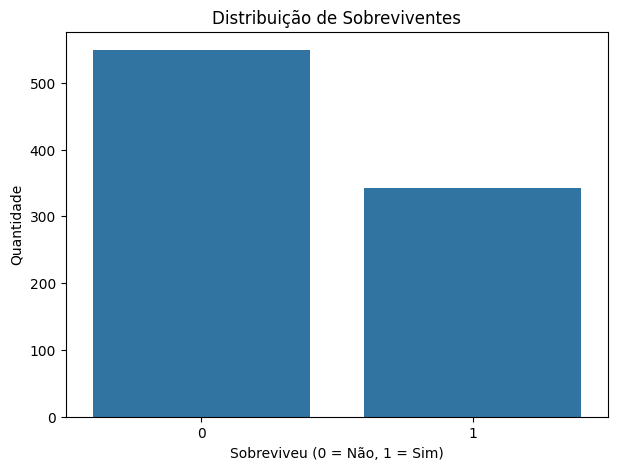

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x='Survived', data=df)

plt.title('Distribuição de Sobreviventes')
plt.xlabel('Sobreviveu (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade')
plt.show()

O gráfico mostra a distribuição dos passageiros entre sobreviventes e não sobreviventes.

Observa-se que a quantidade de pessoas que não sobreviveram é maior do que a de sobreviventes,
indicando um desequilíbrio entre as classes.

## Estatísticas Descritivas

As estatísticas descritivas mostram o comportamento das variáveis numéricas.

A idade média dos passageiros está em torno de 29 anos, com valores variando entre crianças e idosos.

O valor da passagem (Fare) apresenta grande variação, indicando a existência de diferentes classes sociais.

O desvio padrão elevado em algumas variáveis indica alta dispersão dos dados.

In [ ]:
# estatísticas descritivas básicas do dataset
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Média

A média é uma medida de tendência central que representa o valor típico ou o ponto de equilíbrio de um conjunto de dados. É calculada somando-se todos os valores e dividindo-se pelo número total de observações. É sensível a valores extremos (outliers).

In [ ]:
# média dos atributos numéricos do dataset
df.describe().loc['mean']

,mean
PassengerId,446.000000
Survived,0.383838
Pclass,2.308642
Age,29.699118
SibSp,0.523008
Parch,0.381594
Fare,32.204208


### Desvio Padrão

O desvio padrão indica o nível de dispersão dos dados em relação à média.

Observa-se que a variável Fare possui um alto desvio padrão,
o que indica grande variação nos valores das passagens.

Já a variável SibSp apresenta menor variação, indicando comportamento mais homogêneo.

In [ ]:
# desvio padrão dos atributos numéricos do dataset
df.describe().loc['std']

,std
PassengerId,257.353842
Survived,0.486592
Pclass,0.836071
Age,14.526497
SibSp,1.102743
Parch,0.806057
Fare,49.693429


## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

### *Distribuição da Idade*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

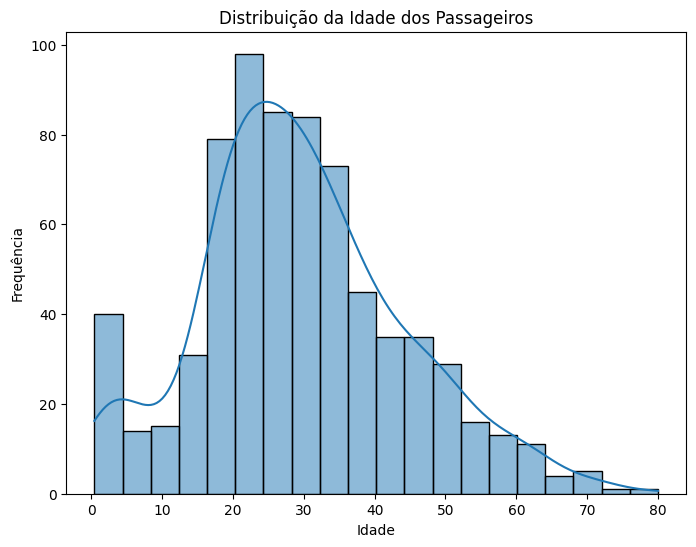

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df['Age'].dropna(), kde=True)

plt.title('Distribuição da Idade dos Passageiros')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

O histograma mostra a distribuição das idades dos passageiros.

Observa-se maior concentração entre jovens adultos,
com presença também de crianças e idosos.

A distribuição não é perfeitamente simétrica,
indicando possível assimetria nos dados.

### *Distribuição de Valor*

Alguma curiosidade ou fato importante sobre o atributo que estamos olhando a distribuição?

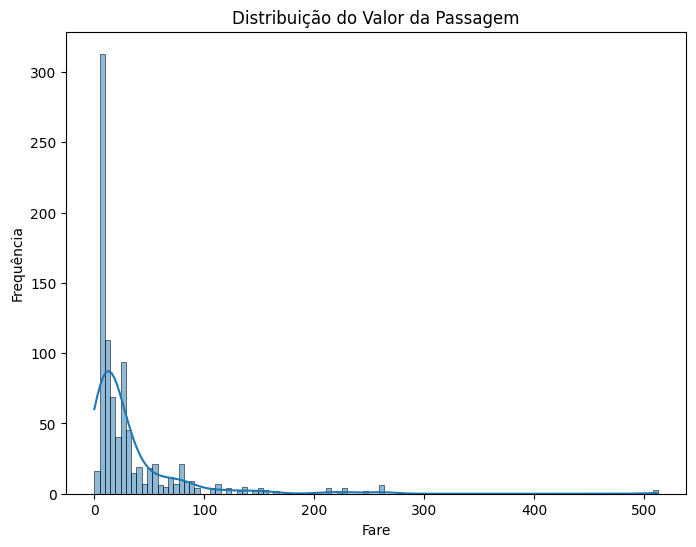

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df['Fare'], kde=True)

plt.title('Distribuição do Valor da Passagem')
plt.xlabel('Fare')
plt.ylabel('Frequência')
plt.show()

A distribuição do valor das passagens apresenta forte assimetria à direita,
indicando que a maioria dos passageiros pagou valores baixos,
enquanto poucos pagaram valores muito altos.

---



## Boxplot

No contexto do dataset Titanic, os boxplots foram utilizados para analisar a relação
entre variáveis como classe dos passageiros (Pclass), valor da passagem (Fare),
idade (Age) e sobrevivência (Survived).

### Distribuição do Valor da Passagem por Classe

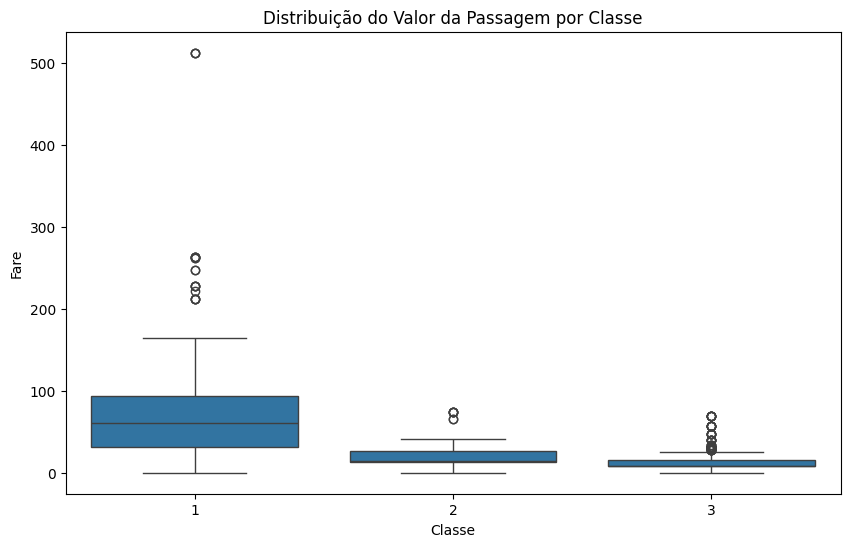

In [ ]:
# Boxplot do comprimento da pétala por espécie
plt.figure(figsize=(10,6))
sns.boxplot(x='Pclass', y='Fare', data=df)

plt.title('Distribuição do Valor da Passagem por Classe')
plt.xlabel('Classe')
plt.ylabel('Fare')
plt.show()

O boxplot mostra que passageiros da primeira classe pagaram valores significativamente mais altos.

Isso reforça a diferença socioeconômica entre as classes,
o que pode influenciar diretamente na taxa de sobrevivência.

### Distribuição da Idade por Sobrevivência

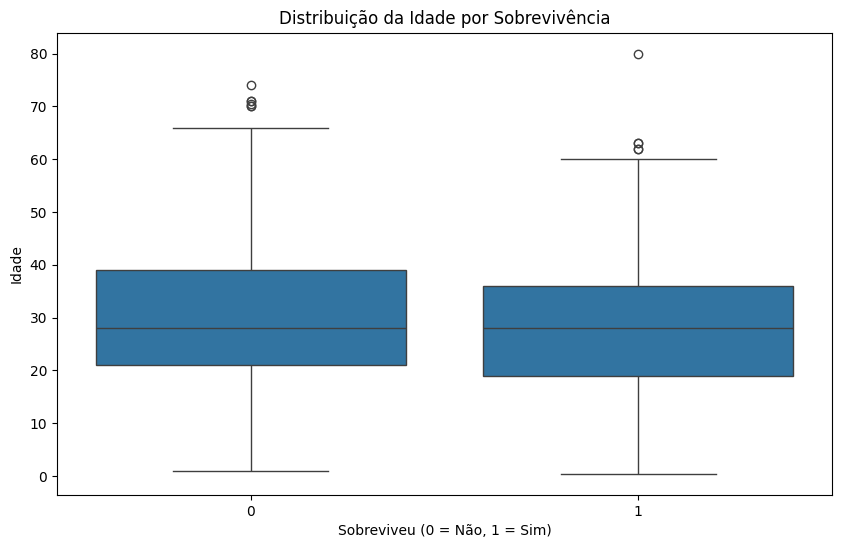

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Survived', y='Age', data=df)

plt.title('Distribuição da Idade por Sobrevivência')
plt.xlabel('Sobreviveu (0 = Não, 1 = Sim)')
plt.ylabel('Idade')
plt.show()

O boxplot indica que passageiros mais jovens apresentaram maior taxa de sobrevivência.

Observa-se que a mediana de idade dos sobreviventes é menor,
sugerindo que crianças e jovens tiveram prioridade durante o resgate.

### Quem pagou mais caro teve mais probabilidade de sobreviver? Vamos ver abaixo!

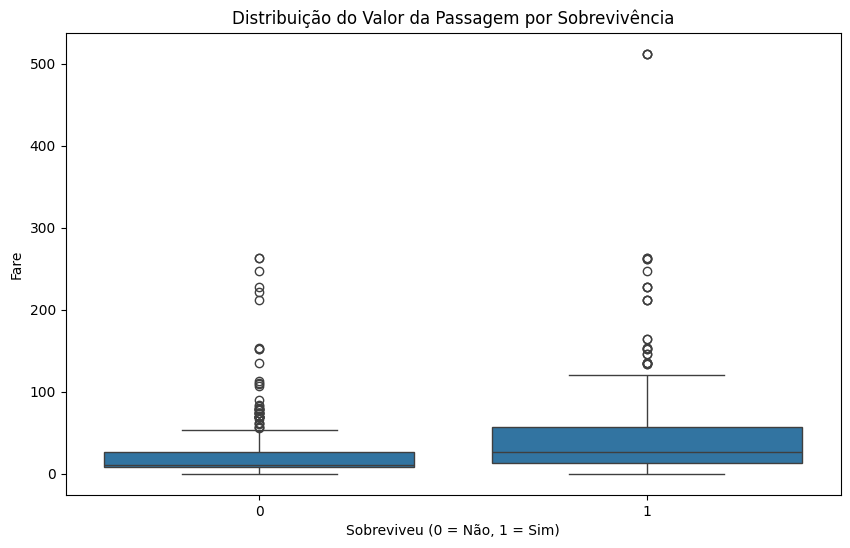

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Survived', y='Fare', data=df)

plt.title('Distribuição do Valor da Passagem por Sobrevivência')
plt.xlabel('Sobreviveu (0 = Não, 1 = Sim)')
plt.ylabel('Fare')
plt.show()

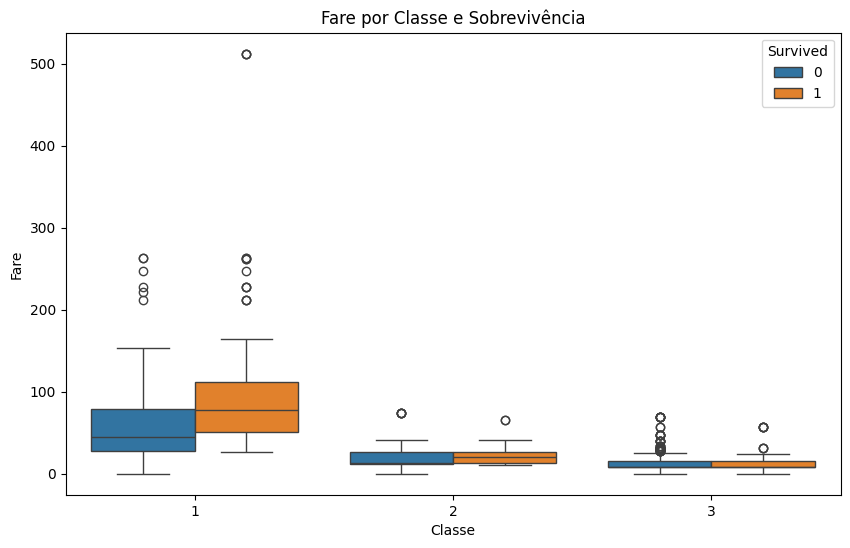

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Pclass', y='Fare', hue='Survived', data=df)

plt.title('Fare por Classe e Sobrevivência')
plt.xlabel('Classe')
plt.ylabel('Fare')
plt.show()

Ao analisar simultaneamente classe e sobrevivência,
observa-se que passageiros da primeira classe com tarifas mais altas
tiveram maior taxa de sobrevivência.

Isso reforça a influência da classe social no desfecho dos passageiros.

## Matriz de Correlação

A matriz de correlação mostra a relação entre variáveis numéricas.

Observa-se que a variável Pclass possui correlação negativa com Fare,
indicando que classes mais altas pagam valores maiores.

A variável Survived apresenta correlação com algumas variáveis,
como Fare e Pclass, sugerindo influência na sobrevivência.

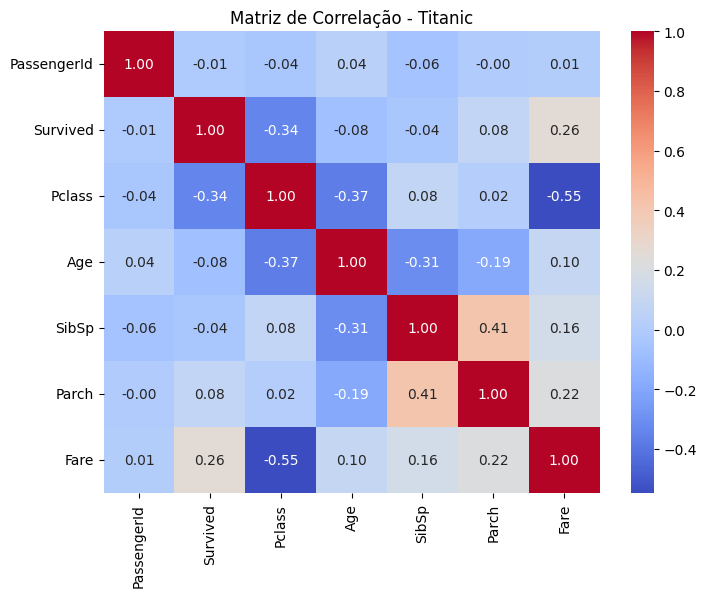

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Matriz de Correlação - Titanic')
plt.show()

## Tratamento de Valores Nulos

Observa-se a presença de valores nulos nas colunas:

- Age
- Cabin
- Embarked

Esses valores precisarão ser tratados antes da modelagem,
pois podem impactar negativamente os resultados.

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [ ]:
# Selecionar variáveis relevantes
df_model = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']].copy() # Criando um novo Dataframe chamado df_model para não alterar o dataset original

# Converter variável categórica
df_model['Sex'] = df_model['Sex'].map({'male': 0, 'female': 1}) #Transformando texto em número pois o ML não aceita texto

# Tratar valores nulos da idade
df_model['Age'] = df_model['Age'].fillna(df_model['Age'].mean()) # Substituíndo "Nan" pela Média das Idades

# Separar X e y
X = df_model.drop('Survived', axis=1)
y = df_model['Survived'] #Target

Para o pré-processamento, foram selecionadas variáveis relevantes para análise:
classe (Pclass), sexo (Sex), idade (Age) e valor da passagem (Fare).

A variável categórica "Sex" foi convertida para valores numéricos.

Valores nulos da variável idade foram preenchidos com a média,
garantindo consistência nos dados.

A variável alvo (y) é "Survived", enquanto as demais compõem as features (X).

In [ ]:
# Dividir os dados em conjuntos de treino e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (623, 4)
Dimensões de X_test: (268, 4)
Dimensões de y_train: (623,)
Dimensões de y_test: (268,)


Os dados foram divididos em conjuntos de treino (70%) e teste (30%).

Essa separação permite avaliar o desempenho do modelo em dados não vistos,
evitando overfitting.

## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.



In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_norm = MinMaxScaler()

# Ajustar apenas no treino
scaler_norm.fit(X_train)

# Transformar
X_train_norm = scaler_norm.transform(X_train)
X_test_norm = scaler_norm.transform(X_test)

# Converter para DataFrame
df_norm = pd.DataFrame(X_train_norm, columns=X_train.columns)

print(df_norm.head())

   Pclass  Sex       Age      Fare
0     0.0  0.0  0.044986  0.159777
1     1.0  0.0  0.367921  0.015412
2     1.0  1.0  0.007288  0.021731
3     0.5  0.0  0.447097  0.054164
4     0.5  0.0  0.535059  0.051237


A normalização transforma os dados para um intervalo entre 0 e 1.

Isso é importante para algoritmos que dependem da escala dos dados.

Observa-se que a distribuição dos dados foi mantida,
porém com valores ajustados para uma escala padronizada.

In [ ]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_normalized = scaler_norm.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados normalizados (como DataFrame para melhor visualização)
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())


Primeiras 5 linhas dos dados normalizados (treino):
   Pclass  Sex       Age      Fare
0     0.0  0.0  0.044986  0.159777
1     1.0  0.0  0.367921  0.015412
2     1.0  1.0  0.007288  0.021731
3     0.5  0.0  0.447097  0.054164
4     0.5  0.0  0.535059  0.051237


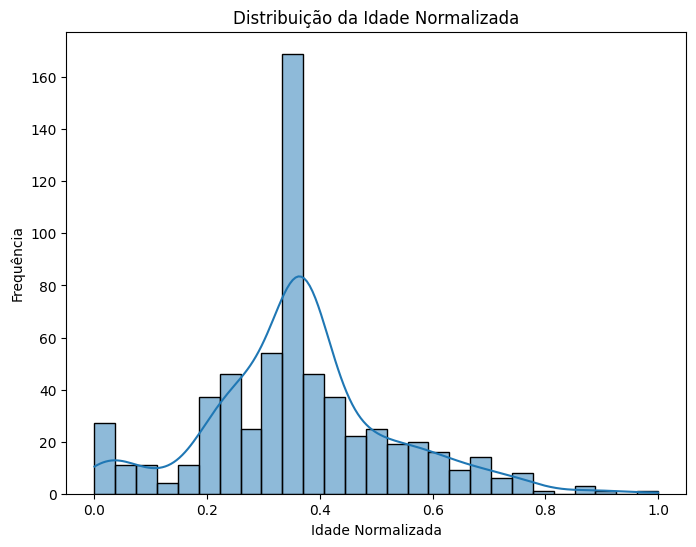

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df_norm['Age'], kde=True)

plt.title('Distribuição da Idade Normalizada')
plt.xlabel('Idade Normalizada')
plt.ylabel('Frequência')
plt.show()

O histograma após a normalização mostra que os valores foram escalados para o intervalo de 0 a 1, mantendo a forma da distribuição original.

## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [ ]:
# Inicializar o StandardScaler
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()

# Ajustar apenas no treino
scaler_std.fit(X_train)

# Transformar
X_train_std = scaler_std.transform(X_train)
X_test_std = scaler_std.transform(X_test)

# Converter para DataFrame
df_std = pd.DataFrame(X_train_std, columns=X_train.columns)

print(df_std.head())

     Pclass       Sex       Age      Fare
0 -1.637881 -0.720772 -1.946947  0.980998
1  0.803267 -0.720772  0.027243 -0.469634
2  0.803267  1.387401 -2.177405 -0.406136
3 -0.417307 -0.720772  0.511273 -0.080232
4 -0.417307 -0.720772  1.049008 -0.109651


In [ ]:
# Aprende média e desvio padrão APENAS de X_train
scaler_std.fit(X_train)
X_train_standardized = scaler_std.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test)

In [ ]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train_standardized, columns=X_train.columns)

In [ ]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
print(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):
     Pclass       Sex       Age      Fare
0 -1.637881 -0.720772 -1.946947  0.980998
1  0.803267 -0.720772  0.027243 -0.469634
2  0.803267  1.387401 -2.177405 -0.406136
3 -0.417307 -0.720772  0.511273 -0.080232
4 -0.417307 -0.720772  1.049008 -0.109651


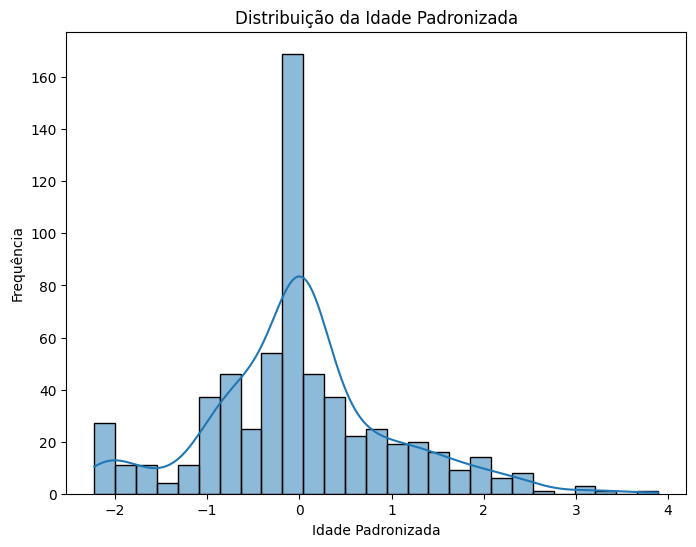

In [ ]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8,6))
sns.histplot(df_std['Age'], kde=True)

plt.title('Distribuição da Idade Padronizada')
plt.xlabel('Idade Padronizada')
plt.ylabel('Frequência')
plt.show()

A padronização transforma os dados para terem média 0 e desvio padrão 1.

Esse processo é importante para algoritmos sensíveis à escala,
como regressão logística e redes neurais.

A distribuição foi centralizada, mantendo o formato original dos dados. Colunas como PassengerId, Name, Ticket e Cabin não foram utilizadas,
pois não contribuem diretamente para a análise preditiva.

## Outras Transformações e Etapas de Pré-Processamento

Outras etapas de pré-processamento incluem a seleção de características, redução de dimensionalidade (como PCA) ou criação de novas características (feature engineering). O que você faria a mais?



# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?



## Hipótese 1

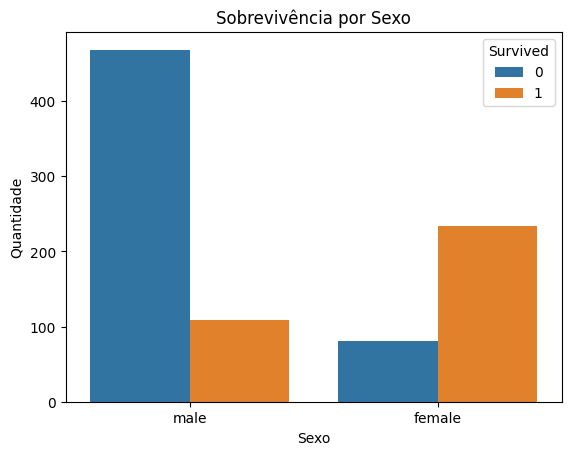

In [ ]:
# hipótese 1 - Quem teve maior chance de sobrevivência: Mulher ou Homem?
sns.countplot(x='Sex', hue='Survived', data=df)

plt.title('Sobrevivência por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Quantidade')
plt.show()

A análise mostra que mulheres tiveram uma taxa de sobrevivência significativamente maior do que homens.

Observa-se que a quantidade de mulheres sobreviventes é proporcionalmente muito superior,
enquanto a maioria dos homens não sobreviveu.

Esse resultado pode ser explicado pela política de evacuação adotada no desastre,
conhecida como "mulheres e crianças primeiro".

## Hipótese 2

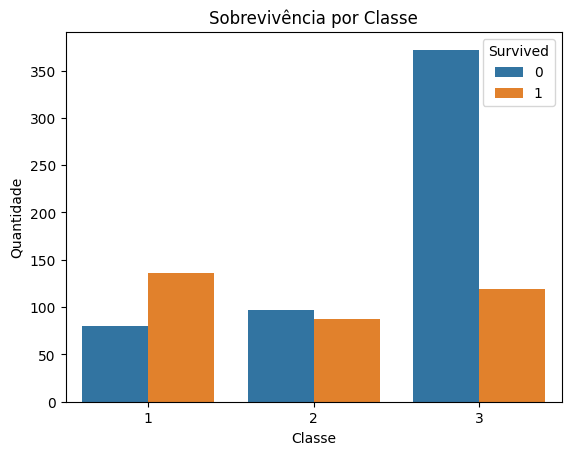

In [ ]:
# hipótese 2 - Entre classes dos passageiros, qual teve maior chance de sobreviver?
sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title('Sobrevivência por Classe')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.show()

Os passageiros da primeira classe apresentaram maior taxa de sobrevivência,
seguidos pela segunda classe, enquanto a terceira classe teve a menor taxa.

Isso evidencia uma forte relação entre classe social e sobrevivência,
indicando que passageiros de classes mais altas tiveram prioridade no resgate.

Esse fator também pode estar relacionado à localização das cabines
e ao acesso mais rápido aos botes salva-vidas.

## Hipótese 3

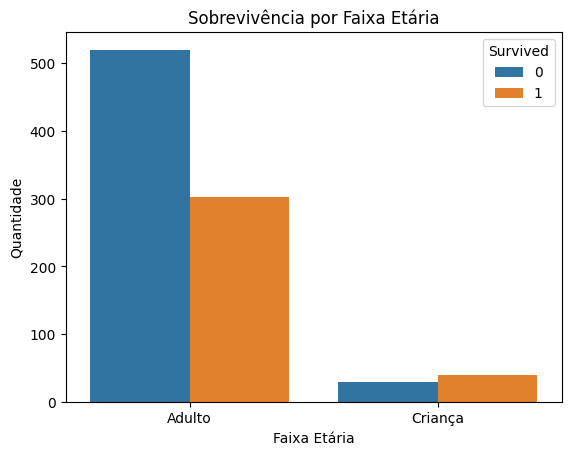

In [ ]:
# hipótese 3 - Entre adultos e crianças, quem teve maior taxa de sobrevivência?
# Criar faixa etária (criança ou adulto)
df['Age_group'] = df['Age'].apply(lambda x: 'Criança' if x < 12 else 'Adulto')

sns.countplot(x='Age_group', hue='Survived', data=df)

plt.title('Sobrevivência por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Quantidade')
plt.show()

A análise indica que crianças tiveram maior taxa de sobrevivência em comparação aos adultos.

Apesar do número total de adultos ser maior, proporcionalmente as crianças sobreviveram mais.

Esse comportamento reforça a política de prioridade no resgate,
em que crianças eram evacuadas antes dos adultos.

Com base nas análises realizadas, todas as hipóteses foram validadas,
e os resultados indicam que fatores sociais e demográficos tiveram forte influência
na sobrevivência dos passageiros.

# Conclusão

A análise exploratória do dataset Titanic permitiu compreender os principais fatores que influenciaram a sobrevivência dos passageiros.

Inicialmente, foi possível observar a estrutura dos dados, identificar variáveis relevantes e tratar inconsistências, como valores nulos na variável idade. Em seguida, foram realizadas análises estatísticas e visuais que possibilitaram identificar padrões importantes no comportamento dos dados.

Os resultados indicam que fatores sociais e demográficos tiveram forte impacto na sobrevivência. Mulheres apresentaram uma taxa significativamente maior de sobrevivência em relação aos homens, reforçando a política de evacuação adotada no desastre. Da mesma forma, passageiros da primeira classe tiveram maiores chances de sobrevivência, evidenciando a influência da classe social e do acesso privilegiado aos recursos de evacuação.

Além disso, a análise por faixa etária mostrou que crianças tiveram prioridade no resgate, apresentando maior proporção de sobreviventes em comparação aos adultos.

Durante o pré-processamento, foram aplicadas técnicas de tratamento de dados, como preenchimento de valores ausentes, codificação de variáveis categóricas e padronização dos dados, garantindo maior qualidade e consistência para futuras etapas de modelagem.

Por fim, conclui-se que o dataset analisado apresenta padrões claros que permitem explicar, de forma consistente, os fatores que influenciaram a sobrevivência no Titanic. O trabalho reforça a importância da análise exploratória e do pré-processamento como etapas fundamentais no processo de ciência de dados, servindo como base para a construção de modelos preditivos mais robustos.